# Phần 1 — Thống kê mô tả & đặc trưng

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)
num_df = df.select_dtypes(include="number")
table = pd.DataFrame({
    "mean": num_df.mean(),
    "median": num_df.median(),
    "mode": num_df.mode().iloc[0],
    "var": num_df.var(),
    "std": num_df.std(),
    "min": num_df.min(),
    "Q1": num_df.quantile(0.25),
    "Q3": num_df.quantile(0.75),
    "max": num_df.max(),
})
table["IQR"] = table["Q3"] - table["Q1"]
print("variable table:")
display(table) 
mean_groups = df.groupby("species").mean(numeric_only=True)
std_groups = df.groupby("species").std(numeric_only=True)
print("Mean group table:")
display(mean_groups)
print("Std group table:")
display(std_groups)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
variable table:


,mean,median,mode,var,std,min,Q1,Q3,max,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,5.1,6.4,7.9,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,2.8,3.3,4.4,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,1.6,5.1,6.9,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,0.3,1.8,2.5,1.5


Mean group table:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Std group table:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


sau khi load dữ liệu Iris của loài hoa, ta print df.head tức là in ra 5 dòng đầu tiên của dataframe. Sau đó data shape tức là kích thước của bảng, với (150,5) tức là có 150 bông hoa và có 5 đặc trưng mỗi bông bao gồm sepal length, sepal width, petal length, petal width và species. còn với dtype tức là kiểu dữ liệu của từng đặc trưng. 

Tiếp theo phần 2 ta tạo một bảng tính các giá trị như mean, median, q1,... rồi display. Đối với mode ta phải dùng iloc[0] bởi vì mode sẽ cho ra một table giống df table, vì thế ta phải thêm iloc[0] để mode chỉ lấy hàng theo label

Cuối cùng ta tính mean và std của từng group species, dựa trên bảng Mean được in ra sau khi tính toán, ta thấy petal length và petal width của setosa nhỏ hơn đáng kể so với những species khác, còn versicolor có giá trị petal lớn trung bình và virginica là species có petal lớn nhất. Ngược lại, sepal width của setosa lại là lớn nhất trong tất cả species và sepal length vẫn là nhỏ nhất. 

Đối với bảng Std ta thấy các giá trị khá nhỏ, đều hơn và không có loài nào đột biến so với loài kia. Tuy nhiên std của virginica lớn hơn hai species còn lại cho thấy species này có tính đa dạng hơn 2 species còn lại.

# Phần 2 — Phân phối xác suất

1) Vẽ histogram + KDE

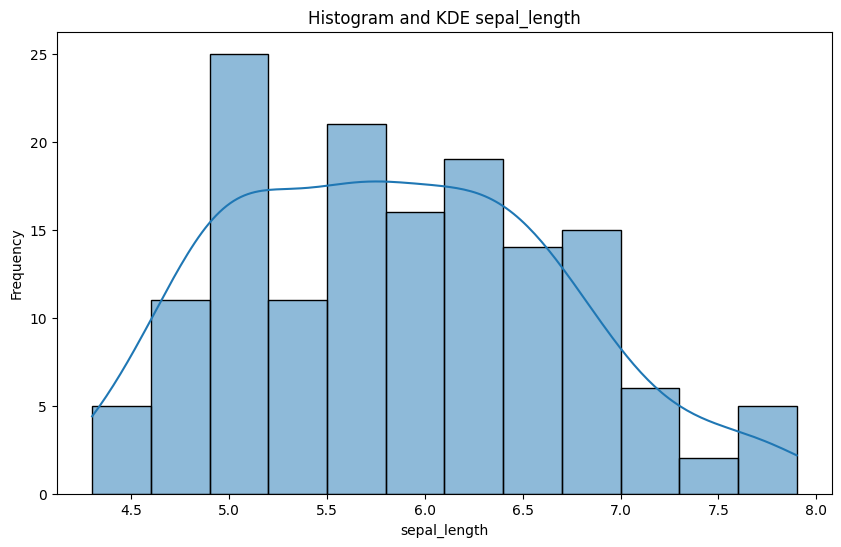

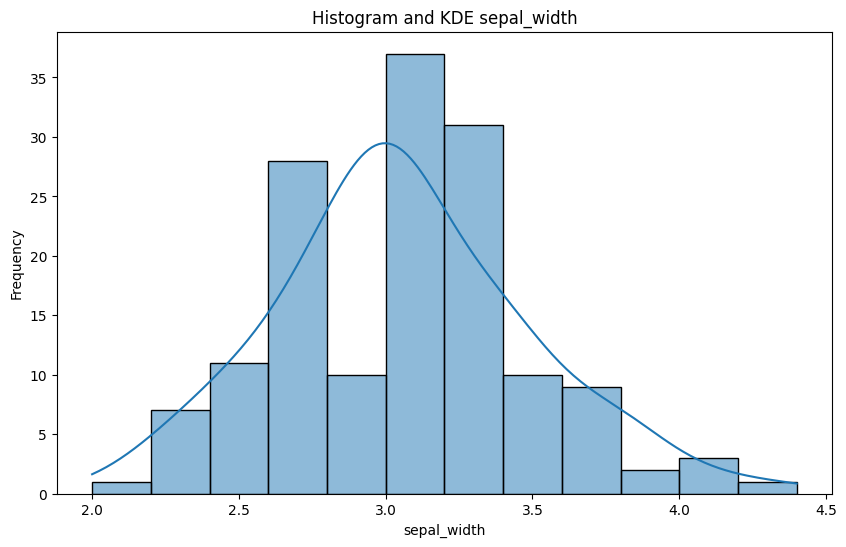

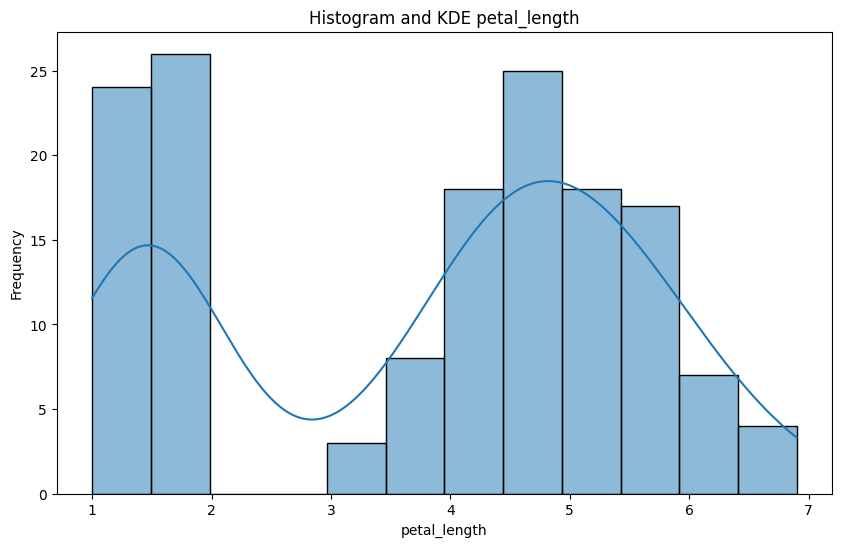

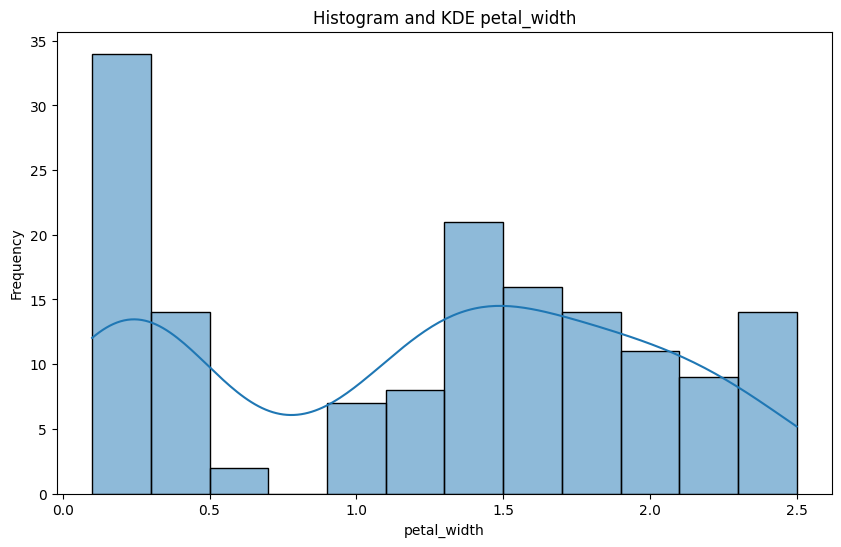

In [2]:
import matplotlib.pyplot as plt
cols = df.select_dtypes(include="number").columns
for col in cols:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True, bins=12)
    plt.title(f"Histogram and KDE {col}")
    plt.ylabel("Frequency")
    plt.show()

Với sepal length, ta thấy gần chuẩn với phân phối chuẩn(gauss) chỉ hơi bị ngang ở phần đỉnh. Đồ thị hơi lệch phải

Với sepal width, ta thấy đây chính là phân phối chuẩn(gauss) cũng là biểu đồ chuẩn nhất của 4 biểu đồ và gần như không lệch

Với petal length, đồ thị đã xuất hiện nhiều đỉnh do sự đa dạng của các species hoa

Với petal width, đồ thị giống với petal length khi có nhiều đỉnh và khác với phân phối chuẩn

2) Vẽ boxplot

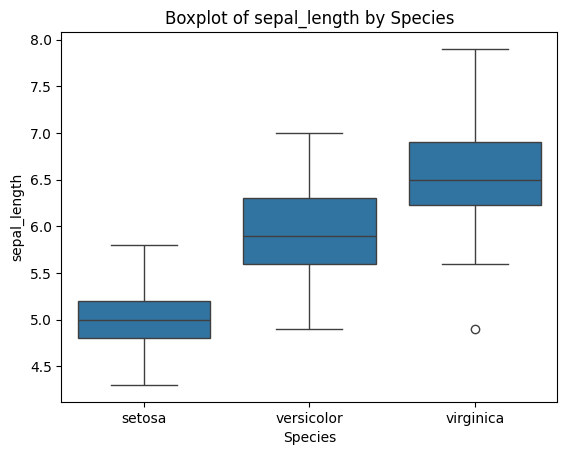

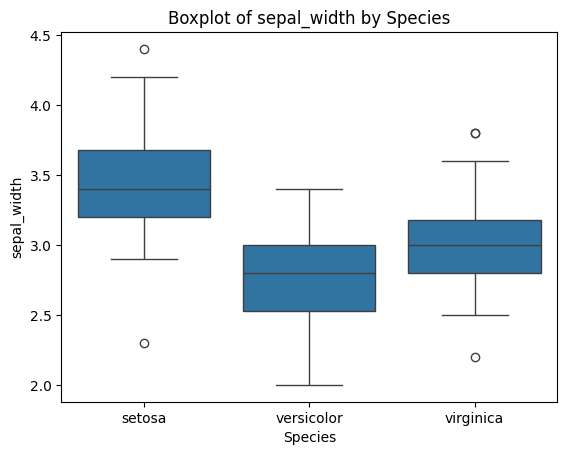

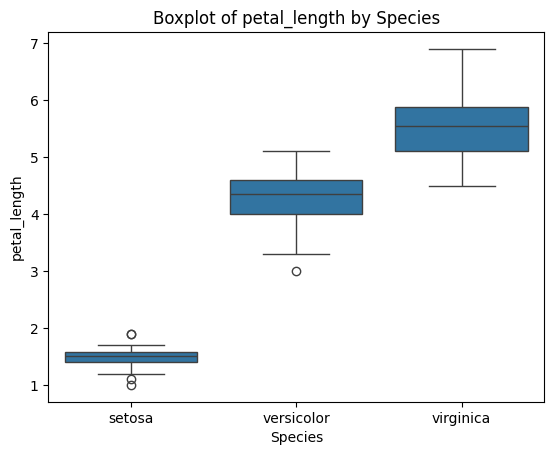

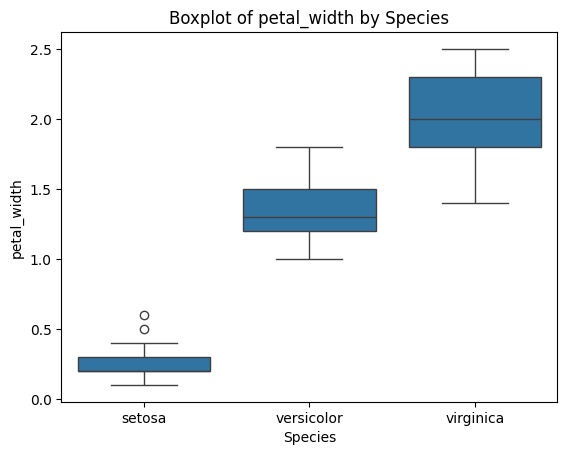

In [3]:
for col in cols:
    sns.boxplot(
        x="species",
        y=col,
        data=df
    )
    plt.title(f"Boxplot of {col} by Species")
    plt.xlabel("Species")
    plt.ylabel(col)
    plt.show()

boxplot của sepal length và sepal width khá giống nhau, box của các species không quá khác biệt setosa có box nhỏ nhất.

còn box pedal thể hiện rõ sự khác biệt giữa ba species. Điều này làm nổi bật sự đa dạng giữa các species.

3) Mô phỏng:

[5.48396968 6.40859361 5.95895049 5.21897974 5.26381496 6.29546391
 6.07696632 4.60495835 5.68425094 6.03881452 4.75737172 6.44120914
 6.80850688 4.93251101 5.62706691 5.36057196 6.24040921 6.06772243
 5.80411766 6.04501662 6.04675693 6.43849964 5.7990299  7.05218753
 6.34185161 5.86323698 5.77440223 3.51685071 6.54436037 6.0338783
 6.07285832 5.10723779 5.8333967  4.44422757 4.99106615 5.08053284
 5.15217266 5.86761305 5.31182535 5.07459764 5.41355697 5.46358515
 6.98778852 6.63250119 5.81229379 6.47355567 6.51748657 6.2837218
 6.22138716 5.34264858 6.68360905 7.72446943 5.26375488 5.09753012
 5.63505017 4.91269444 5.10875708 6.08946365 7.10388231 6.51857041
 6.38657165 5.34575787 5.25321243 6.03330548 6.01222104 4.53020193
 7.2708388  4.91735237 5.27969417 3.81340188 6.8142049  7.03955162
 4.05754064 5.17897644 6.05875203 6.72387498 5.66379324 6.48256416
 6.42273785 7.35336312 4.91904119 6.0596716  5.54052662 5.69157419
 5.7069841  6.0078362  5.62689932 6.54660548 6.52338754 6.172931

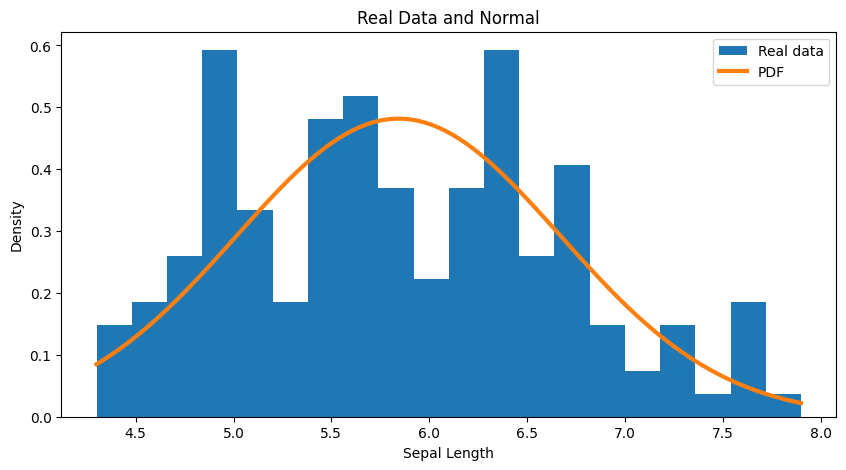

In [4]:
random_feature = df["sepal_length"]
mean = random_feature.mean()
std = random_feature.std()
rand = np.random.normal(
    loc=mean,
    scale=std,
    size=len(random_feature)
)
print(rand)
plt.figure(figsize=(10,5))
plt.hist(
    random_feature,
    bins=20,
    density=True,
    label="Real data"
)
length = np.linspace(random_feature.min(),random_feature.max(),100)
pdf = (1/(std*np.sqrt(2*np.pi)))*np.exp(-((length-mean)**2)/(2*std**2))
plt.plot(
    length,
    pdf,
    linewidth = 3,
    label = "PDF"
)
plt.title("Real Data and Normal")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.legend()
plt.show()

Nhìn vào đồ thị ta thấy dữ liệu thực tế khá giống với PDF lý thuyết nhưng đỉnh đang hơi lệch về hai bên. hai cột cao nhất ở 5.0 và 6.5 đang không ở đúng đinh của phân phối chuẩn. Ta có thể đánh giá chung rằng có điểm tương đồng nhưng không hoàn toàn giống phân phối chuẩn ở phần đỉnh và đuôi.

# Phần 3 — Phân tích đa biến & tương quan

1) Tính ma trận hiệp phương sai (covariance) và tương quan (correlation)

In [5]:
covariance = num_df.cov()
correlation = num_df.corr()
display(covariance)
display(correlation)


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


Ta tháy đối với ma trận tương quan thì petal length và petal width với sepal length  tương quan dương rất mạnh còn sepal width tương quan âm với tất cả các biến còn lại.

2) Vẽ heatmap tương quan

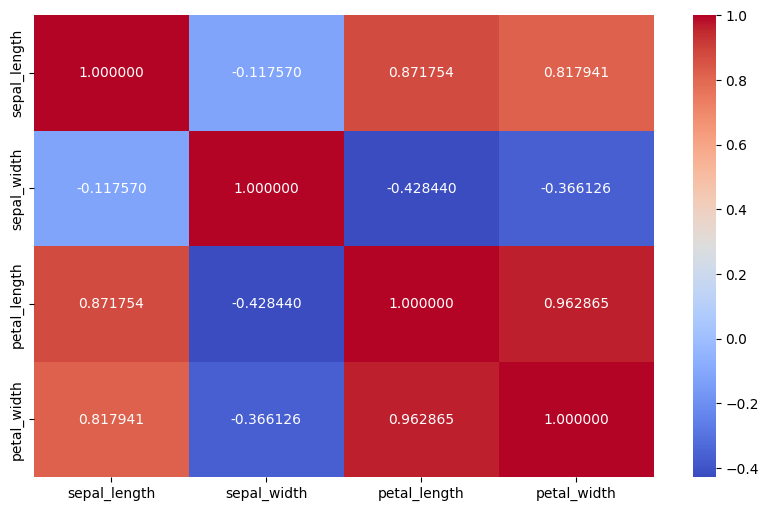

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".6f"
)
plt.show()

Bảng Heatmap tương tự ma trận tương quan ở trên với màu từ xanh đến đỏ tương ứng với tương quan âm đến tương quan dương từ 0 đến 1.

Ta thấy được cặp biến tương quan mạnh nhất chính là petal width với petal length điều này chứng tỏ khi petal của hoa càng lớn thì tương ứng sepal của hoa cũng sẽ tăng kích thước theo.Vì vậy có dấu hiệu đa cộng tuyến ở đây giữa petal length và petal width.

3) Vẽ pairplot

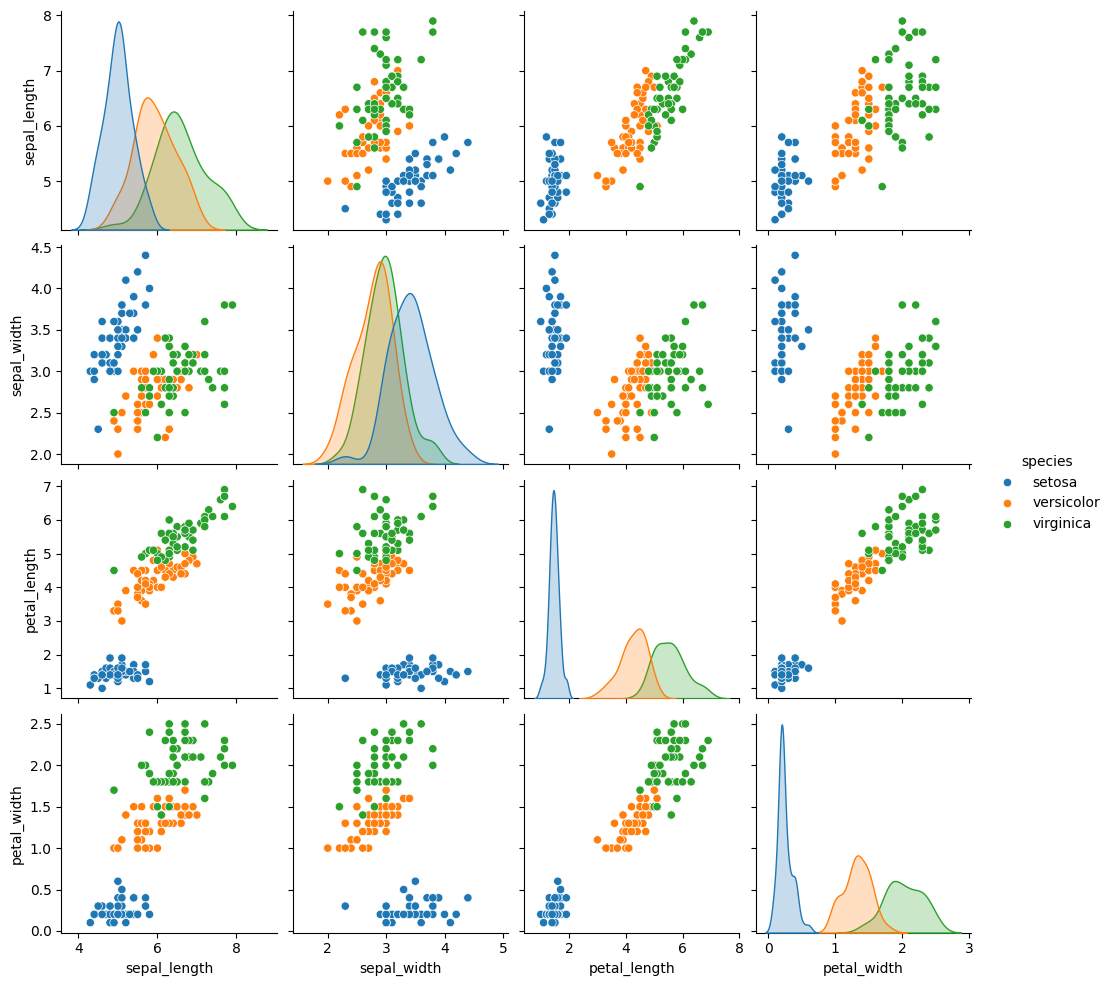

In [7]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="kde"
)
plt.show()

Nhận xét thấy cặp petal length và petal width là đẹp nhất khi các điểm thành một đường thẳng và có 3 cụm rõ ràng. còn sepal length và petal length cùng có xu hướng tăng cùng nhau.Đối với sepal width thì tương quan khá ít với các biến còn lại và phân tán hơn.

# Phần 4 — Xác suất & Định lý Bayes

1) Code xác suất hậu nghiệm

In [15]:
P_B = 0.01
P_not_B = 1-0.01
P_true_pos = 0.99
P_false_pos = 0.05
P = (P_true_pos*P_B)/((P_true_pos*P_B)+(P_false_pos*P_not_B))
print(round(P,4))


0.1667


Ta thấy mặc dù tỉ lệ chính xác đến 99% nhưng do tỉ lệ mắc bệnh quá thấp chỉ có 0.01 và dương tính giả 0.05 đã làm kết quả dương tính nhưng thật sự nhiễm bệnh chỉ có 16,67%.

2. Khảo sát: vẽ đồ thị P (B |+) khi tỉ lệ mắc bệnh P (B) thay đổi từ 0.001 đến 0.2 và giải thích

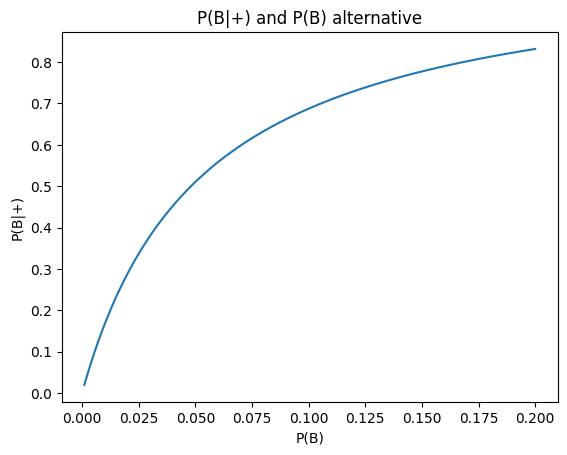

In [16]:
P_B_range = np.linspace(0.001,0.2,300)
P_B_given_pos =(P_true_pos*P_B_range)/((P_true_pos*P_B_range)+(P_false_pos*(1-P_B_range)))
plt.Figure(figsize=(10,6))
plt.plot(
    P_B_range,
    P_B_given_pos,
)
plt.title("P(B|+) and P(B) alternative")
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.show()

Rõ ràng khi tỉ lệ mắc bệnh thấp thì tỉ lệ dương tính thật rất thấp vì số người không bệnh nhiều hơn rất nhiều, nhưng khi tỉ lệ mắc bệnh tăng lên thì dương tính thật tăng lên rõ rệt do độ chính xác của xét nghiệm lên đến 99%. Điều này khiến đồ thị trở thành một đường cong. Do đó ta có thể kết luận khi tỉ lệ nhiễm thấp thì dù kết quả xét nghiệm chính xác cao đến 99% cũng không chắc là thật sự mắc bệnh, từ đó dẫn tới cảm giác "phản trực giác".

3) Naive Bayes

In [26]:
P_spam = 0.3
P_not_spam = 0.7
probability_spam ={
    "free": 0.6,
    "money": 0.8,
    "trial": 0.5,
    "apply": 0.7
}
probability_not_spam={
    "free": 0.25,
    "money": 0.1,
    "trial": 0.3,
    "apply": 0.2
}
def naive_bayes(email):
    P_email_spam=1
    P_email_not_spam=1
    for word in email:
        P_email_spam *= probability_spam[word]
        P_email_not_spam *=probability_not_spam[word]
    result = (P_email_spam*P_spam)/((P_email_spam*P_spam)+(P_email_not_spam*P_not_spam))
    return result
emails = [
    """Hello,
    We are excited to give you a free 30-day trial of our premium service.""",
    """Dear Applicant,
    You can apply for the Software Engineer position through our website.""",
    """Congratulations!
    You have won free money from our rewards program.""",
    """Hello,
    Start your free trial today and apply for certification later.""",
    """Dear Customer,
    Your monthly account summary is available."""
]
keywords = ["free", "money", "apply","trial"]
for i, email in enumerate(emails,1):
    words=[]
    email=email.lower()
    for keyword in keywords:
        if keyword in email:
            words.append(keyword)
    P_email = naive_bayes(words)
    print(f"Email {i}:")
    print(email)
    print(f"Keywords: {words}")
    print(f"P(spam|email) = {P_email:.4f}")
    print(f"=> {'Spam' if P_email > 0.67 else 'Not Spam'}\n")

Email 1:
hello,
    we are excited to give you a free 30-day trial of our premium service.
Keywords: ['free', 'trial']
P(spam|email) = 0.6316
=> Not Spam

Email 2:
dear applicant,
    you can apply for the software engineer position through our website.
Keywords: ['apply']
P(spam|email) = 0.6000
=> Not Spam

Email 3:
congratulations!
    you have won free money from our rewards program.
Keywords: ['free', 'money']
P(spam|email) = 0.8916
=> Spam

Email 4:
hello,
    start your free trial today and apply for certification later.
Keywords: ['free', 'apply', 'trial']
P(spam|email) = 0.8571
=> Spam

Email 5:
dear customer,
    your monthly account summary is available.
Keywords: []
P(spam|email) = 0.3000
=> Not Spam



Ta xây dựng hàm naive bayes dựa trên xác xuất spam là 0.3 và không spam là 0.7, với các từ khóa "money", "free", "apply", "trial" và xác suất của chúng trong mail spam và không spam. Đầu tiên ta tạo hàm naive bayes với xác suất ban đầu là 100%, sau đó điều chỉnh xác suất với mỗi từ khóa xuất hiện bằng công thức P(email|spam)= P("từ khóa 1"|spam)*...*P("từ khóa n"|spam). Sau đó ta tạo ngẫu nhiên 5 email với các từ khóa xuất hiện, ta lọc từ khóa từ các email rồi áp dụng hàm để kiểm tra từng email với threshold là 0.6 xem email đó có spam hay không. với email 5 không có từ khóa nào khớp với dự đoán ta tính ra được xác suất spam là 0.3 khá thấp. Nghĩa là bộ lọc đã hoàn thành với các bước như lọc từ khóa từ email, dùng từ khóa để tính xác suất spam và in ra kết quả.